In [ ]:
# Instalação das bibliotecas necessárias

!pip -q install cdsapi
!pip -q install xarray
!pip -q install netCDF4
!pip -q install cartopy
!pip -q install geopandas
!pip -q install matplotlib
!pip -q install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 80.0 MB/s eta 0:00:00


In [ ]:
import os

#=========================================
# CONFIGURAÇÃO DA API DO COPERNICUS
#=========================================

url = "https://cds.climate.copernicus.eu/api"

key = "6739505d-393f-47e2-88ec-f760bb318422"

with open(os.path.expanduser("~/.cdsapirc"), "w") as f:
    f.write(f"url: {url}\n")
    f.write(f"key: {key}")

print("API configurada com sucesso!")

API configurada com sucesso!


In [ ]:
import cdsapi
import os
import numpy as np
import xarray as xr
import pandas as pd

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
output_folder = "/content/drive/MyDrive/Geomodelagem_Acai"

os.makedirs(output_folder, exist_ok=True)

print(output_folder)

/content/drive/MyDrive/Geomodelagem_Acai


In [ ]:
client = cdsapi.Client()

output_file = os.path.join(
    output_folder,
    "ERA5Land_Para_2024.nc"
)

client.retrieve(

    "reanalysis-era5-land",

    {

        "variable":[
            "2m_temperature",
            "2m_dewpoint_temperature",
            "total_precipitation",
            "10m_u_component_of_wind",
            "10m_v_component_of_wind"
        ],

        "year":"2024",

        "month":[
            "01","02","03","04","05","06",
            "07","08","09","10","11","12"
        ],

        "day":[
            "01","02","03","04","05","06","07","08","09","10",
            "11","12","13","14","15","16","17","18","19","20",
            "21","22","23","24","25","26","27","28","29","30","31"
        ],

        "time":"15:00",

        "data_format":"netcdf",

        # Limites do Estado do Pará
        # Norte, Oeste, Sul, Leste

        "area":[
            2.0,
            -58.5,
            -10.5,
            -46.0
        ]

    },

    output_file

)

print("Download concluído!")
print(output_file)

2026-07-10 21:28:14,721 INFO Request ID is fd8a0883-5132-4ea0-a197-885117ef7650
INFO:ecmwf.datastores.legacy_client:Request ID is fd8a0883-5132-4ea0-a197-885117ef7650
2026-07-10 21:28:14,805 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-10 21:28:36,529 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-07-10 21:32:34,585 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


cba969a70dbda53c0bb215e9c82857d1.zip:   0%|          | 0.00/48.7M [00:00<?, ?B/s]

Download concluído!
/content/drive/MyDrive/Geomodelagem_Acai/ERA5Land_Para_2024.nc


In [ ]:
import zipfile
import os

# Caminho do arquivo baixado
zip_file = output_file

# Pasta onde será extraído
extract_folder = os.path.dirname(zip_file)

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("Arquivos extraídos:")
print(os.listdir(extract_folder))

Arquivos extraídos:
['ERA5Land_Para_2024.nc', 'data_0.nc']


In [ ]:
import glob

arquivos_nc = glob.glob(os.path.join(extract_folder, "*.nc"))

print(arquivos_nc)

['/content/drive/MyDrive/Geomodelagem_Acai/ERA5Land_Para_2024.nc', '/content/drive/MyDrive/Geomodelagem_Acai/data_0.nc']


In [ ]:
import os
import xarray as xr

arquivo_nc = os.path.join(extract_folder, "data_0.nc")

print(arquivo_nc)

ds = xr.open_dataset(arquivo_nc)

ds

/content/drive/MyDrive/Geomodelagem_Acai/data_0.nc


<xarray.Dataset> Size: 116MB
Dimensions:     (valid_time: 366, latitude: 126, longitude: 126)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2024-01-01T15:00:00 ... 2024-...
  * latitude    (latitude) float64 1kB 2.0 1.9 1.8 1.7 ... -10.3 -10.4 -10.5
  * longitude   (longitude) float64 1kB -58.5 -58.4 -58.3 ... -46.2 -46.1 -46.0
    number      int64 8B ...
    expver      (valid_time) <U4 6kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 23MB ...
    d2m         (valid_time, latitude, longitude) float32 23MB ...
    tp          (valid_time, latitude, longitude) float32 23MB ...
    u10         (valid_time, latitude, longitude) float32 23MB ...
    v10         (valid_time, latitude, longitude) float32 23MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-07-10T21:31 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
print("\nVariáveis disponíveis:\n")

for var in ds.data_vars:
    print(var)

temperatura = ds["t2m"] - 273.15

temperatura.attrs["units"] = "°C"

print("Temperatura convertida para Celsius.")

vento = np.sqrt(ds["u10"]**2 + ds["v10"]**2)

vento.attrs["units"] = "m/s"

print("Velocidade do vento calculada.")

precipitacao = ds["tp"] * 1000

precipitacao.attrs["units"] = "mm"

print("Precipitação convertida para mm.")
T = temperatura
Td = ds["d2m"] - 273.15

# Pressão de saturação
es = 6.112 * np.exp((17.67 * T) / (T + 243.5))

# Pressão real de vapor
e = 6.112 * np.exp((17.67 * Td) / (Td + 243.5))

# Umidade relativa (%)
umidade = 100 * (e / es)

umidade.attrs["units"] = "%"

print("Umidade relativa calculada.")


Variáveis disponíveis:

t2m
d2m
tp
u10
v10
Temperatura convertida para Celsius.
Velocidade do vento calculada.
Precipitação convertida para mm.
Umidade relativa calculada.


In [ ]:
dados = xr.Dataset(

    data_vars={

        "temperatura": temperatura,

        "precipitacao": precipitacao,

        "vento": vento,

        "umidade": umidade

    },

    coords={

        "time": ds.valid_time,
        "latitude": ds.latitude,
        "longitude": ds.longitude

    }

)

dados

<xarray.Dataset> Size: 93MB
Dimensions:       (valid_time: 366, latitude: 126, longitude: 126)
Coordinates:
  * valid_time    (valid_time) datetime64[ns] 3kB 2024-01-01T15:00:00 ... 202...
  * latitude      (latitude) float64 1kB 2.0 1.9 1.8 1.7 ... -10.3 -10.4 -10.5
  * longitude     (longitude) float64 1kB -58.5 -58.4 -58.3 ... -46.1 -46.0
    number        int64 8B 0
    expver        (valid_time) <U4 6kB ...
    time          (valid_time) datetime64[ns] 3kB 2024-01-01T15:00:00 ... 202...
Data variables:
    temperatura   (valid_time, latitude, longitude) float32 23MB 28.69 ... 27.32
    precipitacao  (valid_time, latitude, longitude) float32 23MB 0.2165 ... 9.73
    vento         (valid_time, latitude, longitude) float32 23MB 2.392 ... 2.762
    umidade       (valid_time, latitude, longitude) float32 23MB 59.53 ... 69.84

In [ ]:
for nome in dados.data_vars:

    print(f"\n===== {nome.upper()} =====")

    print(f"Mínimo : {float(dados[nome].min()):.2f}")

    print(f"Máximo : {float(dados[nome].max()):.2f}")

    print(f"Média   : {float(dados[nome].mean()):.2f}")


===== TEMPERATURA =====
Mínimo : 19.64
Máximo : 39.83
Média   : 30.61

===== PRECIPITACAO =====
Mínimo : 0.00
Máximo : 359.54
Média   : 2.43

===== VENTO =====
Mínimo : 0.00
Máximo : 10.20
Média   : 1.96

===== UMIDADE =====
Mínimo : 9.79
Máximo : 100.02
Média   : 59.76


In [ ]:
print(dados.time)

print("\nPrimeiras datas:")

print(dados.time.values[:10])

mes = dados.valid_time.dt.month

<xarray.DataArray 'time' (valid_time: 366)> Size: 3kB
array(['2024-01-01T15:00:00.000000000', '2024-01-02T15:00:00.000000000',
       '2024-01-03T15:00:00.000000000', ..., '2024-12-29T15:00:00.000000000',
       '2024-12-30T15:00:00.000000000', '2024-12-31T15:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 2024-01-01T15:00:00 ... 2024-...
    number      int64 8B 0
    expver      (valid_time) <U4 6kB ...
    time        (valid_time) datetime64[ns] 3kB 2024-01-01T15:00:00 ... 2024-...
    estacao     (valid_time) <U9 13kB 'Verão' 'Verão' ... 'Verão' 'Verão'
Attributes:
    long_name:      time
    standard_name:  time

Primeiras datas:
['2024-01-01T15:00:00.000000000' '2024-01-02T15:00:00.000000000'
 '2024-01-03T15:00:00.000000000' '2024-01-04T15:00:00.000000000'
 '2024-01-05T15:00:00.000000000' '2024-01-06T15:00:00.000000000'
 '2024-01-07T15:00:00.000000000' '2024-01-08T15:00:00.000000000'
 '2024-01-09T15:00:00.000000000' '

In [ ]:
def identificar_estacao(mes):

    if mes in [12,1,2]:
        return "Verão"

    elif mes in [3,4,5]:
        return "Outono"

    elif mes in [6,7,8]:
        return "Inverno"

    else:
        return "Primavera"

In [ ]:
# Recriando os meses a partir da dimensão correta
meses_valores = dados.valid_time.dt.month.values
estacoes_lista = [identificar_estacao(m) for m in meses_valores]

# Atribuindo a coordenada 'estacao' vinculada à dimensão 'valid_time'
dados = dados.assign_coords(estacao=("valid_time", estacoes_lista))

# Agora o groupby funcionará corretamente separando os meses
medias = dados.groupby("estacao").mean(dim="valid_time")

medias

<xarray.Dataset> Size: 1MB
Dimensions:       (estacao: 4, latitude: 126, longitude: 126)
Coordinates:
  * estacao       (estacao) object 32B 'Inverno' 'Outono' 'Primavera' 'Verão'
  * latitude      (latitude) float64 1kB 2.0 1.9 1.8 1.7 ... -10.3 -10.4 -10.5
  * longitude     (longitude) float64 1kB -58.5 -58.4 -58.3 ... -46.1 -46.0
    number        int64 8B 0
Data variables:
    temperatura   (estacao, latitude, longitude) float32 254kB 27.91 ... 27.82
    precipitacao  (estacao, latitude, longitude) float32 254kB 3.142 ... 4.217
    vento         (estacao, latitude, longitude) float32 254kB 1.34 ... 2.469
    umidade       (estacao, latitude, longitude) float32 254kB 73.24 ... 62.36

In [ ]:
# Garante que o agrupamento reduza a dimensão valid_time para gerar médias espaciais por estação
medias = dados.groupby("estacao").mean(dim="valid_time")

# Verificação rápida: as médias devem ser diferentes agora
for est in medias.estacao.values:
    valor_medio = float(medias["temperatura"].sel(estacao=est).mean())
    print(f"Média de Temperatura em {est}: {valor_medio:.2f} °C")

Média de Temperatura em Inverno: 31.46 °C
Média de Temperatura em Outono: 29.04 °C
Média de Temperatura em Primavera: 32.76 °C
Média de Temperatura em Verão: 28.72 °C


In [ ]:
print(medias)

<xarray.Dataset> Size: 1MB
Dimensions:       (estacao: 4, latitude: 126, longitude: 126)
Coordinates:
  * estacao       (estacao) object 32B 'Inverno' 'Outono' 'Primavera' 'Verão'
  * latitude      (latitude) float64 1kB 2.0 1.9 1.8 1.7 ... -10.3 -10.4 -10.5
  * longitude     (longitude) float64 1kB -58.5 -58.4 -58.3 ... -46.1 -46.0
    number        int64 8B 0
Data variables:
    temperatura   (estacao, latitude, longitude) float32 254kB 27.91 ... 27.82
    precipitacao  (estacao, latitude, longitude) float32 254kB 3.142 ... 4.217
    vento         (estacao, latitude, longitude) float32 254kB 1.34 ... 2.469
    umidade       (estacao, latitude, longitude) float32 254kB 73.24 ... 62.36


In [ ]:
verao = medias.sel(estacao="Verão")

outono = medias.sel(estacao="Outono")

inverno = medias.sel(estacao="Inverno")

primavera = medias.sel(estacao="Primavera")

In [ ]:
variaveis = {

    "temperatura":{

        "titulo":"Temperatura do ar",

        "unidade":"°C",

        "cmap":"turbo"

    },

    "precipitacao":{

        "titulo":"Precipitação",

        "unidade":"mm",

        "cmap":"Blues"

    },

    "vento":{

        "titulo":"Velocidade do vento",

        "unidade":"m/s",

        "cmap":"viridis"

    },

    "umidade":{

        "titulo":"Umidade relativa",

        "unidade":"%",

        "cmap":"YlGnBu"

    }

}

In [ ]:
lista_estacoes = [

    "Verão",

    "Outono",

    "Inverno",

    "Primavera"

]

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [85]:
import os

def plotar_mapa(estacao, variavel):
    # O dataset 'medias' já teve a dimensão 'valid_time' reduzida pelo groupby
    dado = medias.sel(estacao=estacao)[variavel]

    fig = plt.figure(figsize=(8,6))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Usando as configurações do dicionário 'variaveis' se existirem
    config = variaveis.get(
        variavel,
        {"titulo": variavel, "unidade": "", "cmap": "coolwarm"}
    )

    mapa = ax.contourf(
        dado.longitude,
        dado.latitude,
        dado,
        cmap=config["cmap"],
        transform=ccrs.PlateCarree()
    )

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    plt.colorbar(
        mapa,
        label=f"{config['titulo']} ({config['unidade']})"
    )

    plt.title(f"{config['titulo']} - Estação {estacao}")

    # Caminho da pasta onde as figuras serão salvas
    pasta = "/content/drive/MyDrive/Geomogelagem_Acai/Figuras"
    os.makedirs(pasta, exist_ok=True)

    # Nome do arquivo
    nome_arquivo = f"{variavel}_{estacao}.png".replace(" ", "_")

    # Salvar imagem
    plt.savefig(
        os.path.join(pasta, nome_arquivo),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

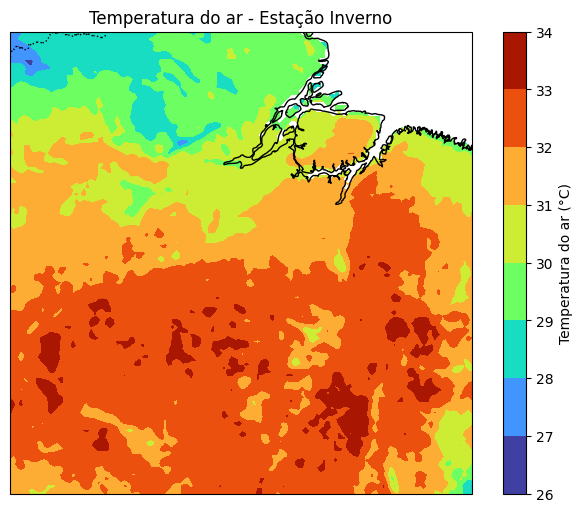

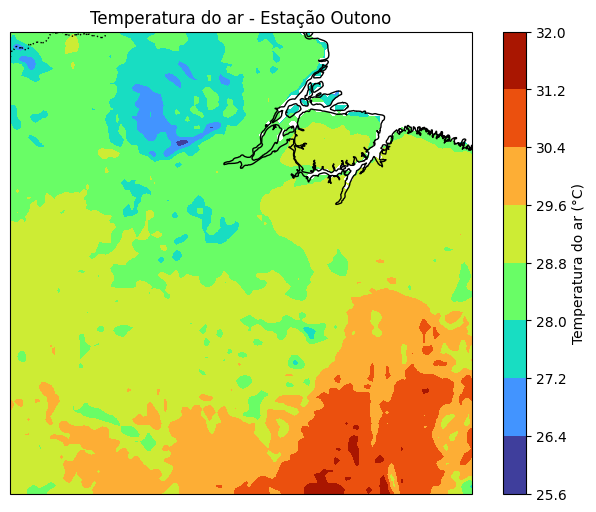

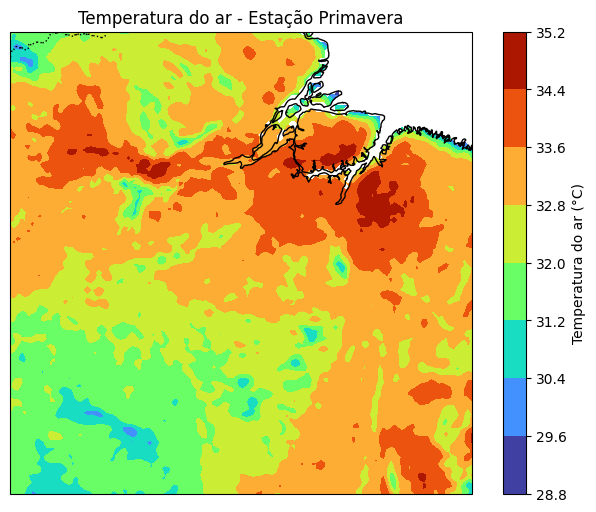

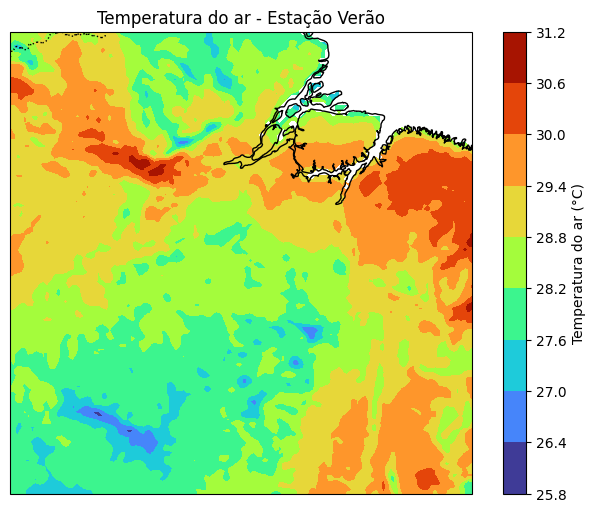

In [86]:
for estacao in lista_estacoes:
    plotar_mapa(estacao, "temperatura")

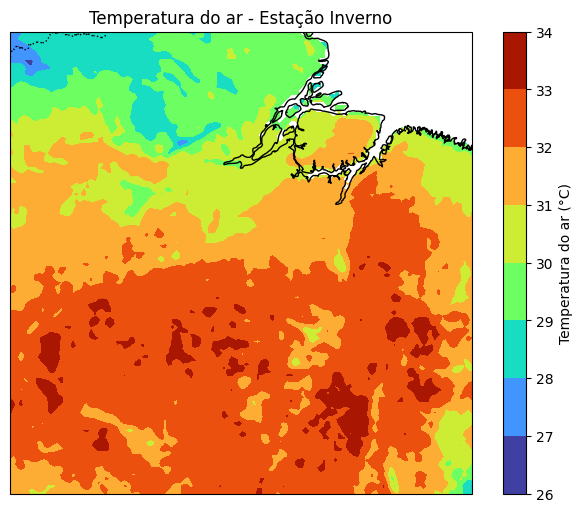

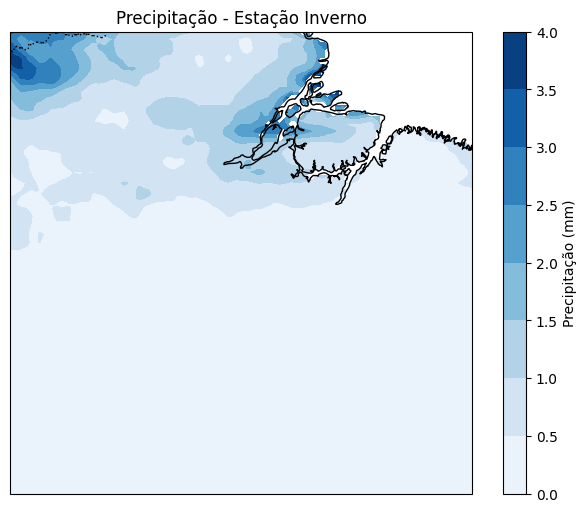

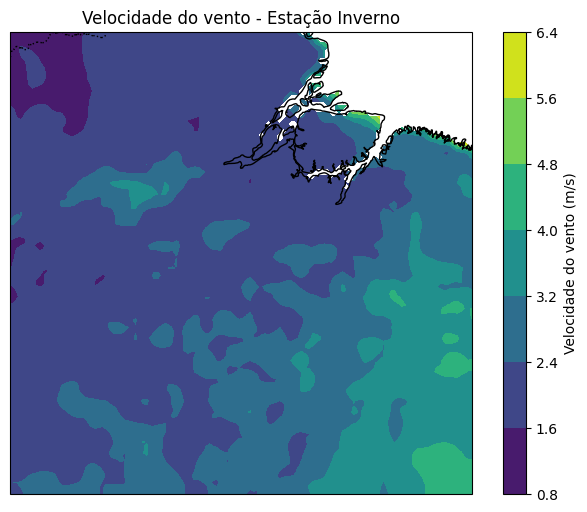

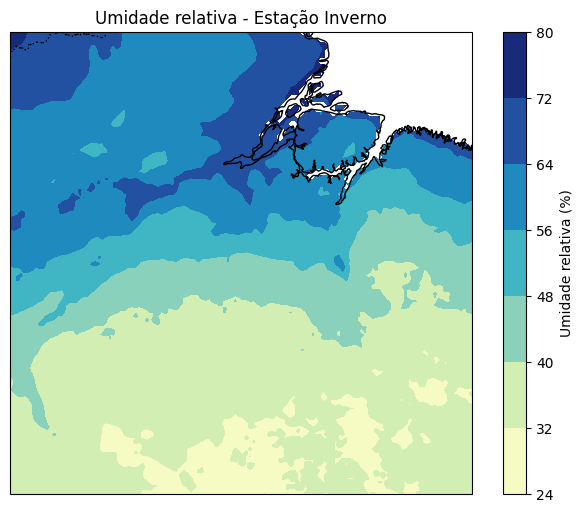

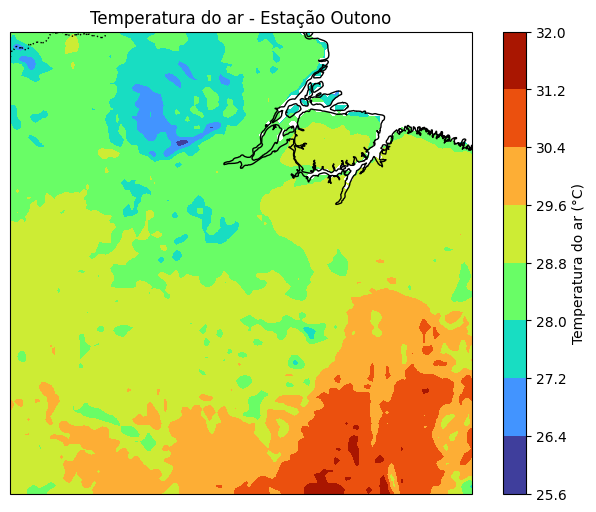

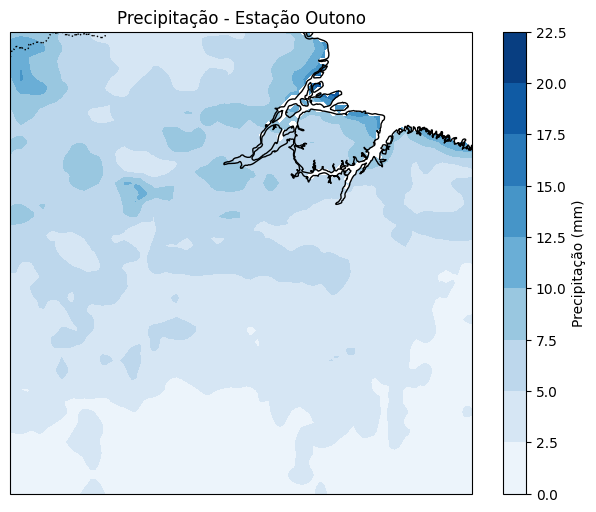

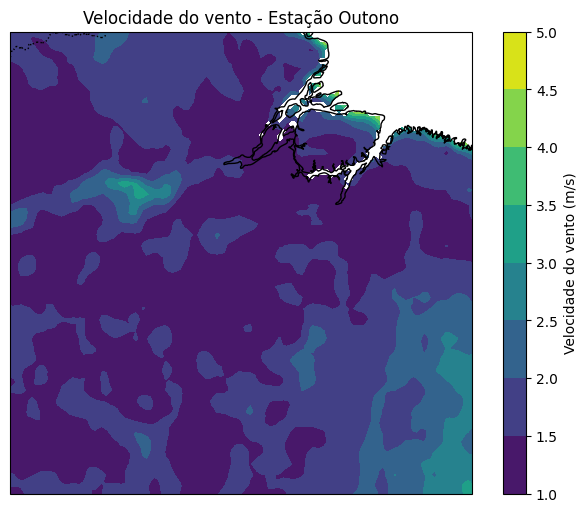

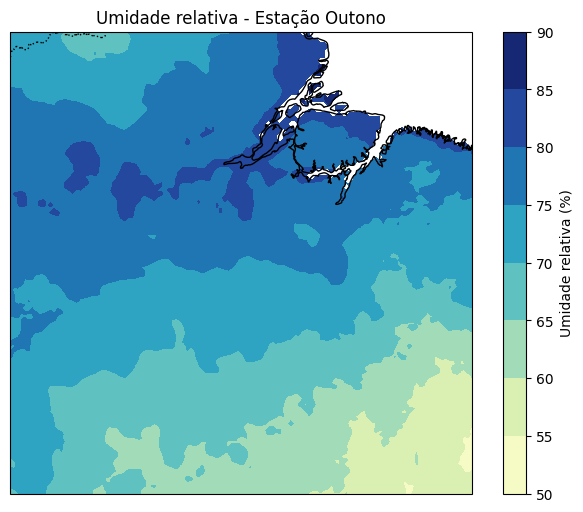

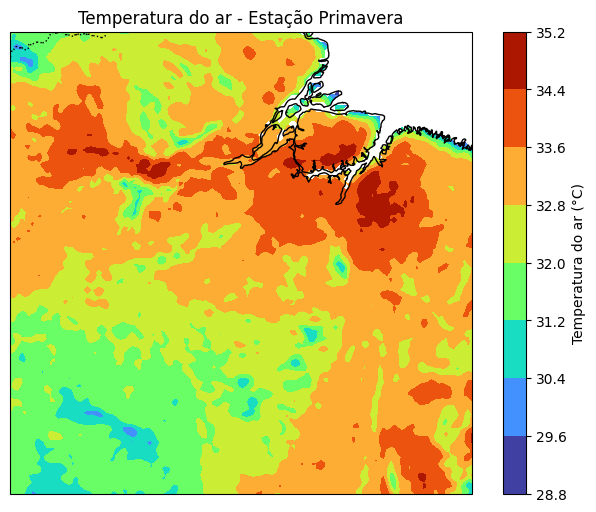

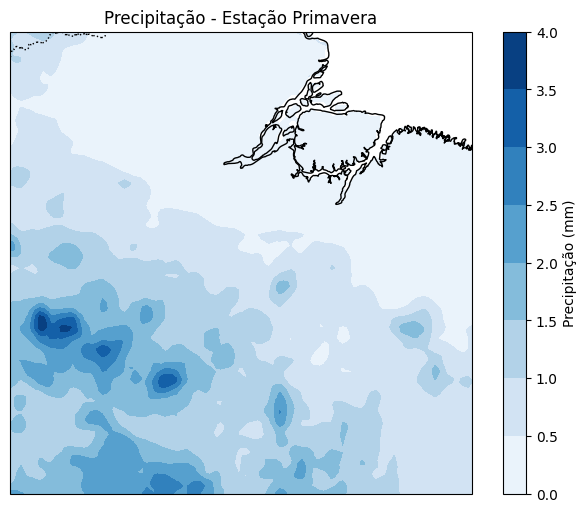

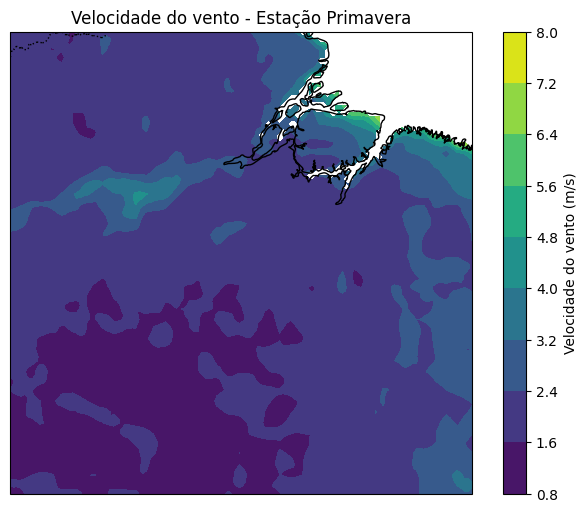

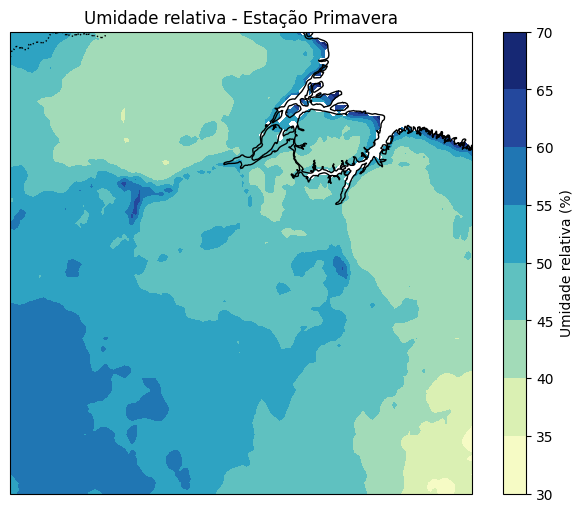

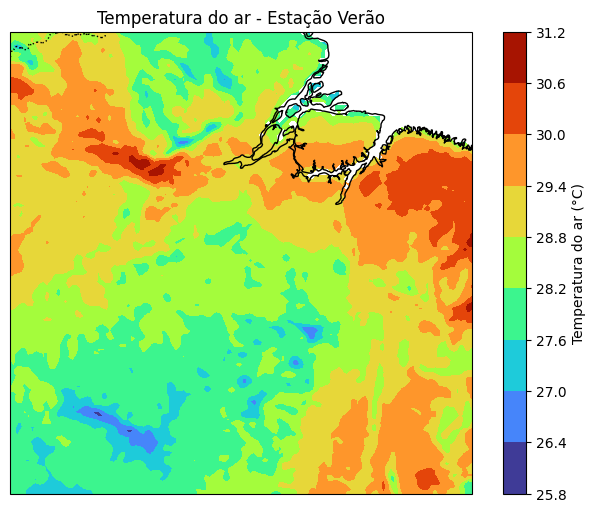

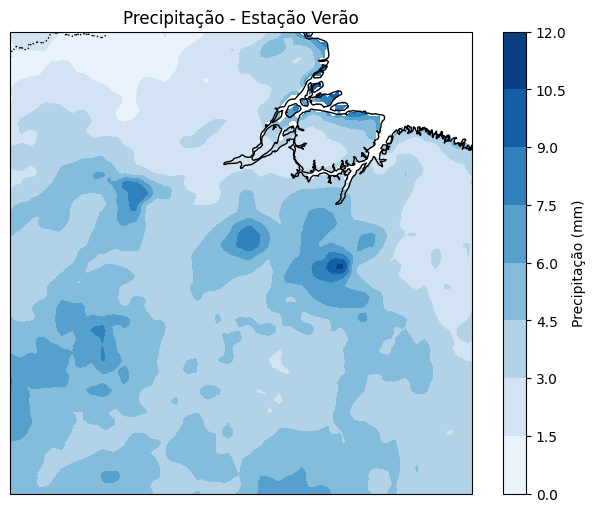

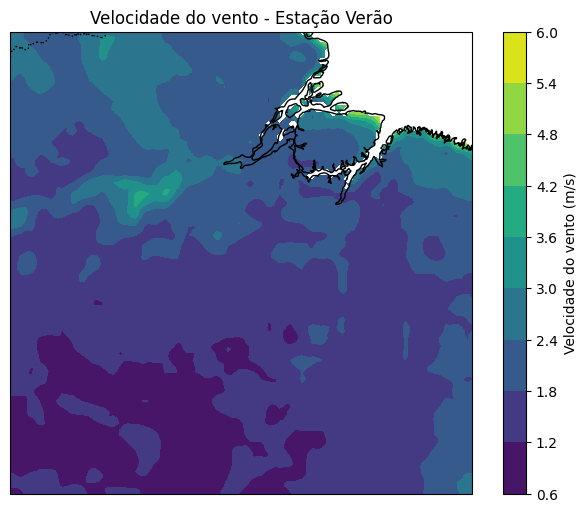

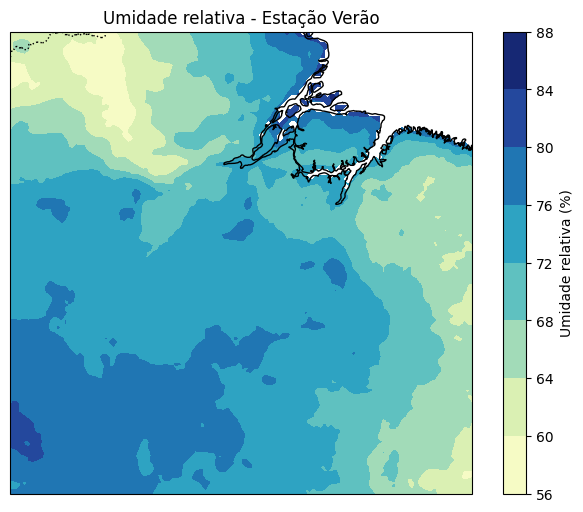

In [87]:
for estacao in lista_estacoes:
    for variavel in variaveis_plot:
        plotar_mapa(estacao, variavel)

In [ ]:
import os

pasta = "/content/drive/MyDrive/Geomogelagem_Acai"

print(os.path.exists(pasta))
medias.to_dataframe().to_csv("/content/drive/MyDrive/Geomodelagem_Acai/dados_climaticos_estacoes.csv")

False
